# Proyecto Machine Learning: LIMPIEZA DE DATOS Y EDA

### Análisis predictivo de la gestión de la ayuda humanitaria y el impacto de desastres a nivel global

In [135]:
# Librerías

import os
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [136]:
# Comprobar ruta hacia mis datos

csv_path = (Path("__file__").parent / ".." / "data" / "enhanced_global_disaster_response.csv").resolve()
print(csv_path)          # imprime la ruta absoluta resuelta
print(csv_path.exists()) # debe imprimir True

C:\Users\cchia\Desktop\Ejercicios y apuntes\Mi Carpeta\2026-02-BILBAO-FT-Data-Science\3-Machine_Learning\ML_project\src\data\enhanced_global_disaster_response.csv
True


In [64]:
# Leer datos

base_dir = os.path.dirname(os.path.abspath("__file__"))  # carpeta del notebook
csv_path = os.path.join(base_dir, "..", "data", "enhanced_global_disaster_response.csv")
df = pd.read_csv(csv_path)

df.head()

,year,country,disaster_type,severity_index,casualties,economic_loss,response_hours,aid_amount,response_score,recovery_days
0,2022,Bangladesh,Flood,0.2,7,"€1,495.00",35.0,€368.00,19.51,112.00
1,2015,Indonesia,Flood,0.1,0,"€16,669.50",2.0,"€6,728.00",100.00,111.00
2,2023,Indonesia,Landslide,0.6,6,"€18,001.00",10.0,"€2,875.00",80.49,103.00
3,2016,Bangladesh,Storm Surge,0.2,9,"€110,843.00",47.0,"€6,070.00",0.00,153.00
4,2018,Japan,Storm Surge,0.6,5,"€10,860.00",8.0,"€8,268.00",85.37,9.00


In [65]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49972 entries, 0 to 49971
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   year            49972 non-null  int64  
 1   country         49972 non-null  object 
 2   disaster_type   49972 non-null  object 
 3   severity_index  49972 non-null  float64
 4   casualties      49972 non-null  int64  
 5   economic_loss   49971 non-null  object 
 6   response_hours  49972 non-null  float64
 7   aid_amount      49972 non-null  object 
 8   response_score  49972 non-null  float64
 9   recovery_days   49972 non-null  object 
dtypes: float64(3), int64(2), object(5)
memory usage: 3.8+ MB


## LIMPIEZA

* Eliminar el nulo que hay:

In [66]:
df = df.dropna()

* Quitar símbolos de "€" y convertir a float:

In [67]:
df["economic_loss"] = df["economic_loss"].str.replace("€", "", regex=False)
df["economic_loss"] = df["economic_loss"].str.replace(",", "", regex=False)
df["economic_loss"] = df["economic_loss"].astype(float)

df["aid_amount"] = df["aid_amount"].str.replace("€", "", regex=False)
df["aid_amount"] = df["aid_amount"].str.replace(",", "", regex=False)
df["aid_amount"] = df["aid_amount"].astype(float)

* Eliminar fila vacía, quitar espacios y pasar recovery_days a numérica:

In [68]:
# Filtrar filas donde la columna contiene no-números y no-puntos
print(df[df["recovery_days"].str.contains(r'[^0-9.]', regex=True, na=False)])
df = df.drop(df.index[25128])

       year  country disaster_type  severity_index  casualties  economic_loss  \
25128  1995  Ireland       Drought             1.6          38       960000.0   

       response_hours  aid_amount  response_score recovery_days  
25128            24.0    119040.0           46.34                


In [69]:
df["recovery_days"] = df["recovery_days"].str.replace(" ", "", regex=False)
df["recovery_days"] = df["recovery_days"].astype(float)

In [70]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 49970 entries, 0 to 49971
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   year            49970 non-null  int64  
 1   country         49970 non-null  object 
 2   disaster_type   49970 non-null  object 
 3   severity_index  49970 non-null  float64
 4   casualties      49970 non-null  int64  
 5   economic_loss   49970 non-null  float64
 6   response_hours  49970 non-null  float64
 7   aid_amount      49970 non-null  float64
 8   response_score  49970 non-null  float64
 9   recovery_days   49970 non-null  float64
dtypes: float64(6), int64(2), object(2)
memory usage: 4.2+ MB


## EDA

In [71]:
df.describe()

,year,severity_index,casualties,economic_loss,response_hours,aid_amount,response_score,recovery_days
count,49970.000000,49970.000000,49970.000000,4.997000e+04,49970.000000,4.997000e+04,49970.000000,49970.000000
mean,2013.048429,2.451687,45.253372,1.069268e+06,15.359296,1.537703e+05,69.303721,136.828017
std,8.005320,1.756624,988.434768,2.388225e+06,14.810454,3.796407e+05,27.839454,183.930851
min,1990.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000e+00,0.000000,2.000000
25%,2007.000000,1.100000,8.000000,1.200000e+05,6.000000,9.300000e+03,56.100000,36.000000
50%,2014.000000,2.200000,21.000000,3.000000e+05,11.000000,3.477506e+04,78.050000,70.000000
75%,2020.000000,3.400000,48.000000,9.660198e+05,20.000000,1.188399e+05,90.240000,154.000000
max,2024.000000,10.000000,170000.000000,6.800000e+07,168.000000,1.171790e+07,100.000000,1797.000000


Outliers en severity_index, casualties, economic_loss, response_hours, aid_amount, recovery_days --> Todas con muchos datos a la izq, y algunos pocos datos muy muy altos.  
Response_score sigue el patrón contrario, con pocos datos a la izquierda y muchos a la derecha.

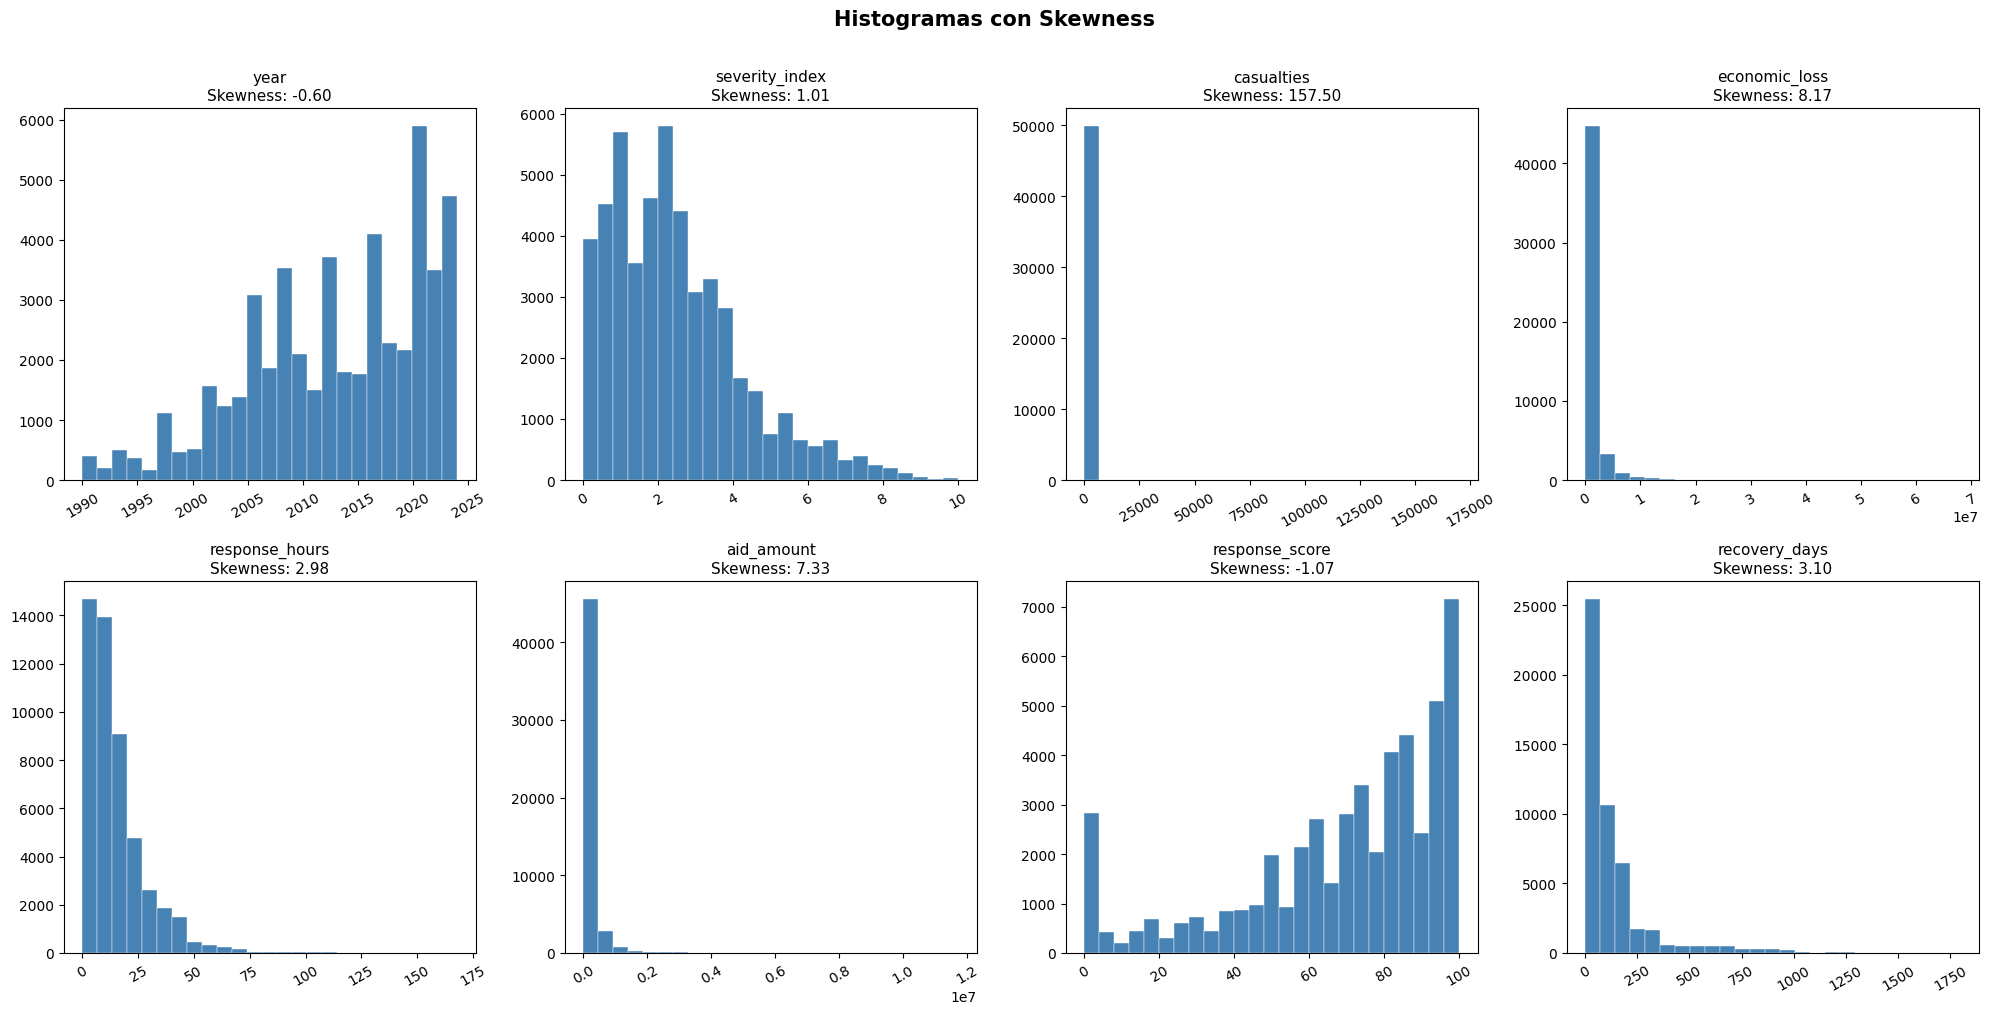

In [72]:
columnas_numericas = df.select_dtypes(include='number').columns.tolist()

fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(20, 10))
axes = axes.flatten()

for i, col in enumerate(columnas_numericas):
    skewness = df[col].skew()
    axes[i].hist(df[col], bins=25, color='steelblue', edgecolor='white', linewidth=0.3)
    axes[i].set_title(f"{col}\nSkewness: {skewness:.2f}", fontsize=11)
    axes[i].set_xlabel("")
    axes[i].tick_params(axis='x', rotation=30)

# Ocultar subplots sobrantes si los hay
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("Histogramas con Skewness", fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show();

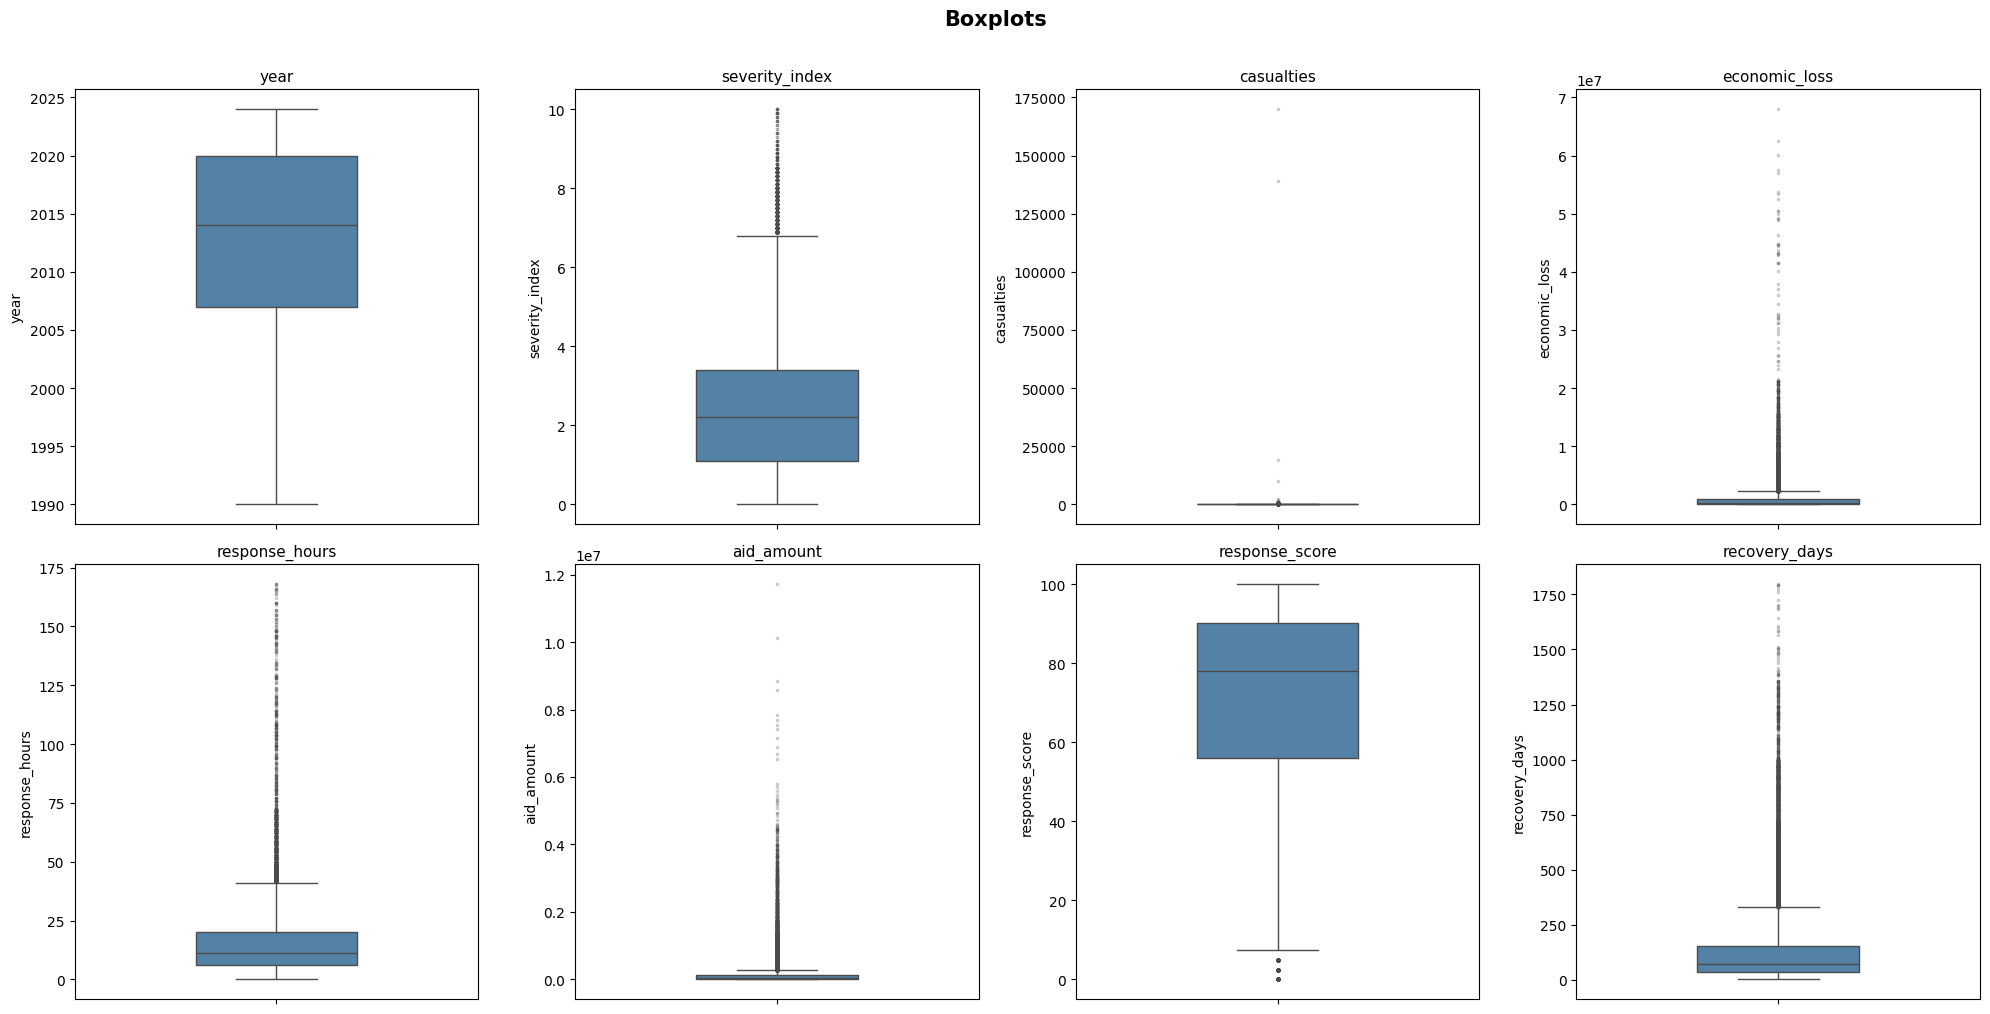

In [73]:
fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(20, 10))
axes = axes.flatten()

for i, col in enumerate(columnas_numericas):
    sns.boxplot(y=df[col], ax=axes[i], color='steelblue', width=0.4,
                flierprops=dict(marker='o', markersize=1.5, alpha=0.3))
    axes[i].set_title(col, fontsize=11)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("Boxplots", fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show();

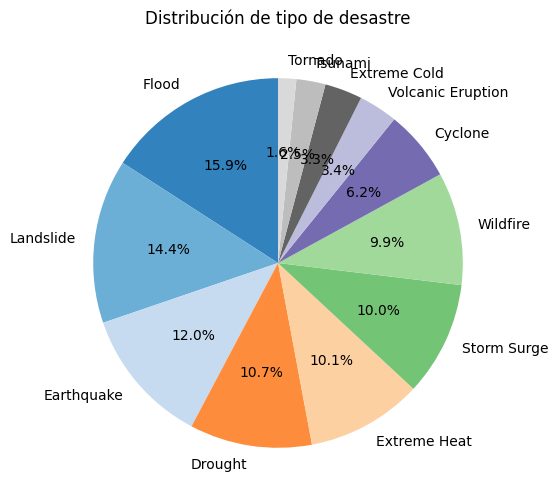

In [ ]:
frecuencias = df['disaster_type'].value_counts()

cmap = plt.get_cmap("tab20c")
colores = cmap(np.linspace(0, 1, len(frecuencias)))

plt.figure(figsize=(6, 6))
plt.pie(frecuencias, labels=frecuencias.index, colors=colores, autopct='%1.1f%%', startangle=90)
plt.title('Distribución de tipo de desastre')
plt.show();

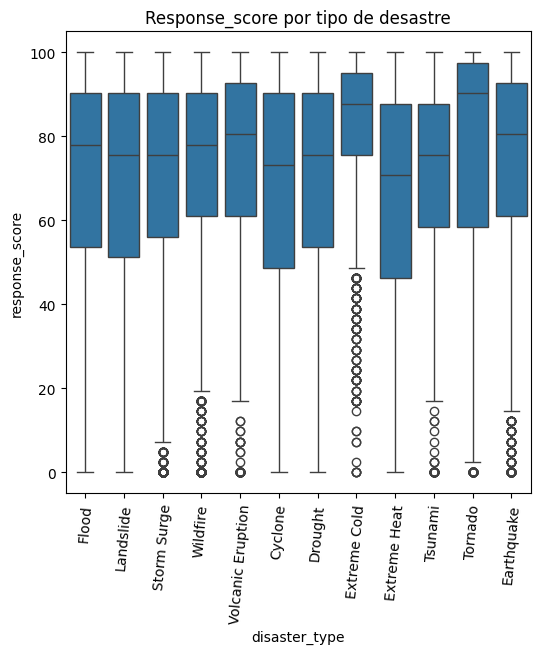

In [99]:
plt.figure(figsize=(6, 6))
sns.boxplot(data=df, x='disaster_type', y='response_score')
plt.xticks(rotation=85) 
plt.title('Response_score por tipo de desastre')
plt.show();

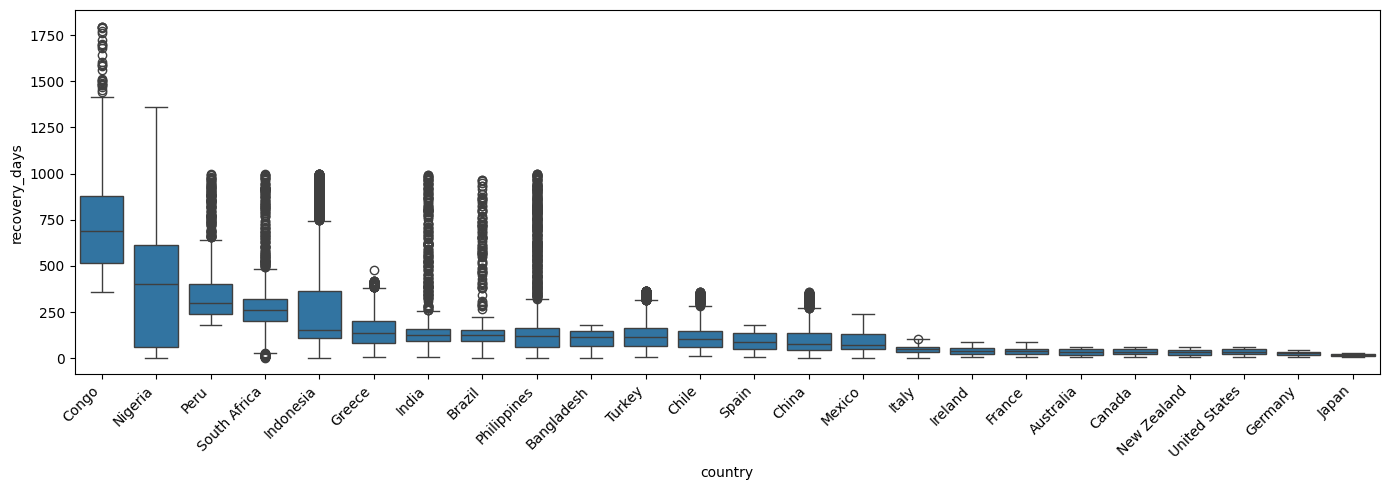

In [107]:
order = df.groupby('country')['recovery_days'].median().sort_values(ascending=False).index.tolist()

plt.figure(figsize=(14, 5))
sns.boxplot(data=df, x='country', y='recovery_days', order=order)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show();

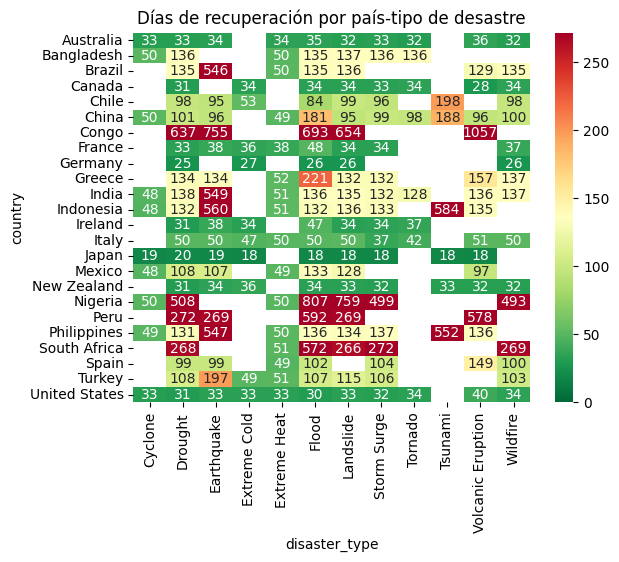

In [114]:
pivot = df.pivot_table('recovery_days', 'country', 'disaster_type', aggfunc='mean')

vmax = np.nanpercentile(pivot.values, 90)

sns.heatmap(pivot, annot=True, fmt='.0f', cmap='RdYlGn_r', vmin=0, vmax=vmax)
plt.title('Días de recuperación por país-tipo de desastre')
plt.show();

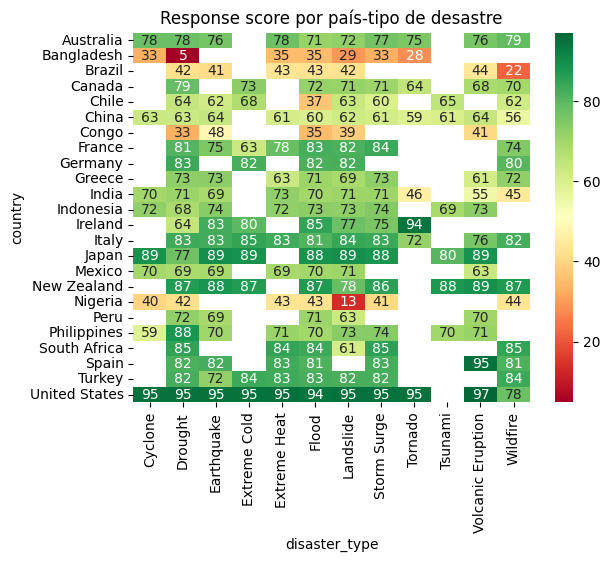

In [104]:
pivot = df.pivot_table('response_score', 'country', 'disaster_type', aggfunc='mean')
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='RdYlGn')
plt.title('Response score por país-tipo de desastre')
plt.show();

In [76]:
df.corr(numeric_only=True)

,year,severity_index,casualties,economic_loss,response_hours,aid_amount,response_score,recovery_days
year,1.000000,0.004881,-0.022473,0.001499,-0.294910,0.000920,0.283200,0.004802
severity_index,0.004881,1.000000,0.058026,0.380669,0.027842,0.345328,-0.019195,0.046524
casualties,-0.022473,0.058026,1.000000,0.051150,0.063764,0.065699,-0.050019,0.014461
economic_loss,0.001499,0.380669,0.051150,1.000000,-0.025874,0.871294,0.029204,0.117641
response_hours,-0.294910,0.027842,0.063764,-0.025874,1.000000,-0.012486,-0.914840,0.183720
aid_amount,0.000920,0.345328,0.065699,0.871294,-0.012486,1.000000,0.013876,0.151341
response_score,0.283200,-0.019195,-0.050019,0.029204,-0.914840,0.013876,1.000000,-0.189071
recovery_days,0.004802,0.046524,0.014461,0.117641,0.183720,0.151341,-0.189071,1.000000


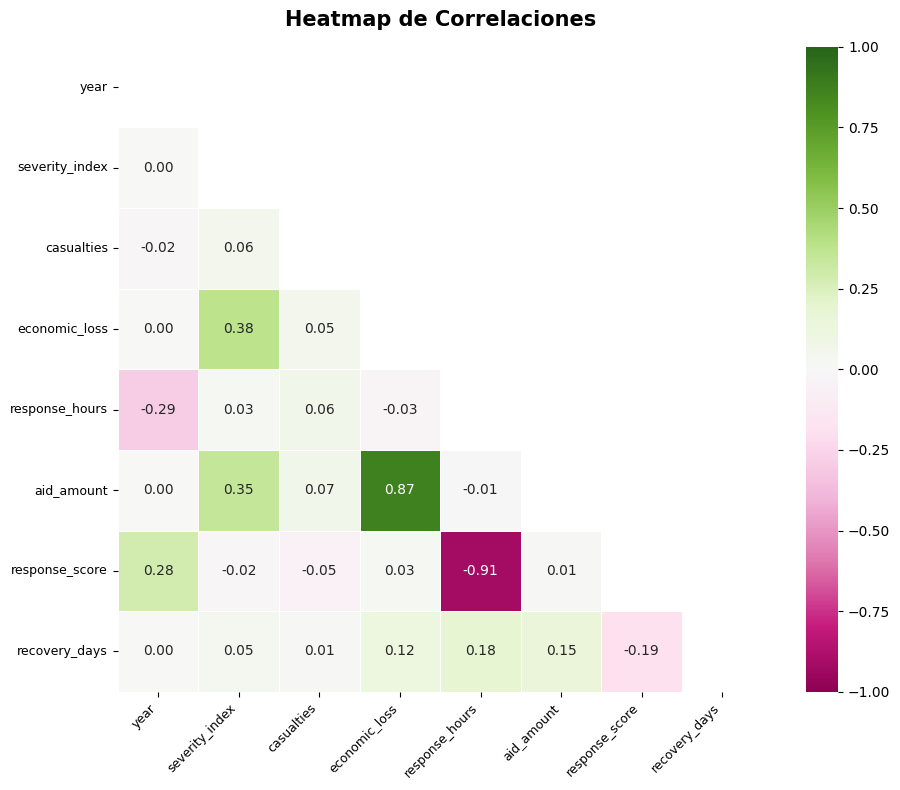

In [77]:
corr_matrix = df[columnas_numericas].corr()

# Máscara para el triángulo superior (evita duplicados)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

fig, ax = plt.subplots(figsize=(10, 8))

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="PiYG",
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.5,
    linecolor='white',
    square=True,
    ax=ax
)

ax.set_title("Heatmap de Correlaciones", fontsize=15, fontweight='bold', pad=15)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.show();

Como es de esperar, response_score está estrechamente relacionada con response_hours: cuanto más horas se tarda en responder, menor es el score que recibes en la respuesta.  
También hay mucha relación entre aid_amount (el dinero que recibes) y economic_loss (el dinero que se ha perdido por el desastre): a más pérdida económica, mayor dinero recibido.

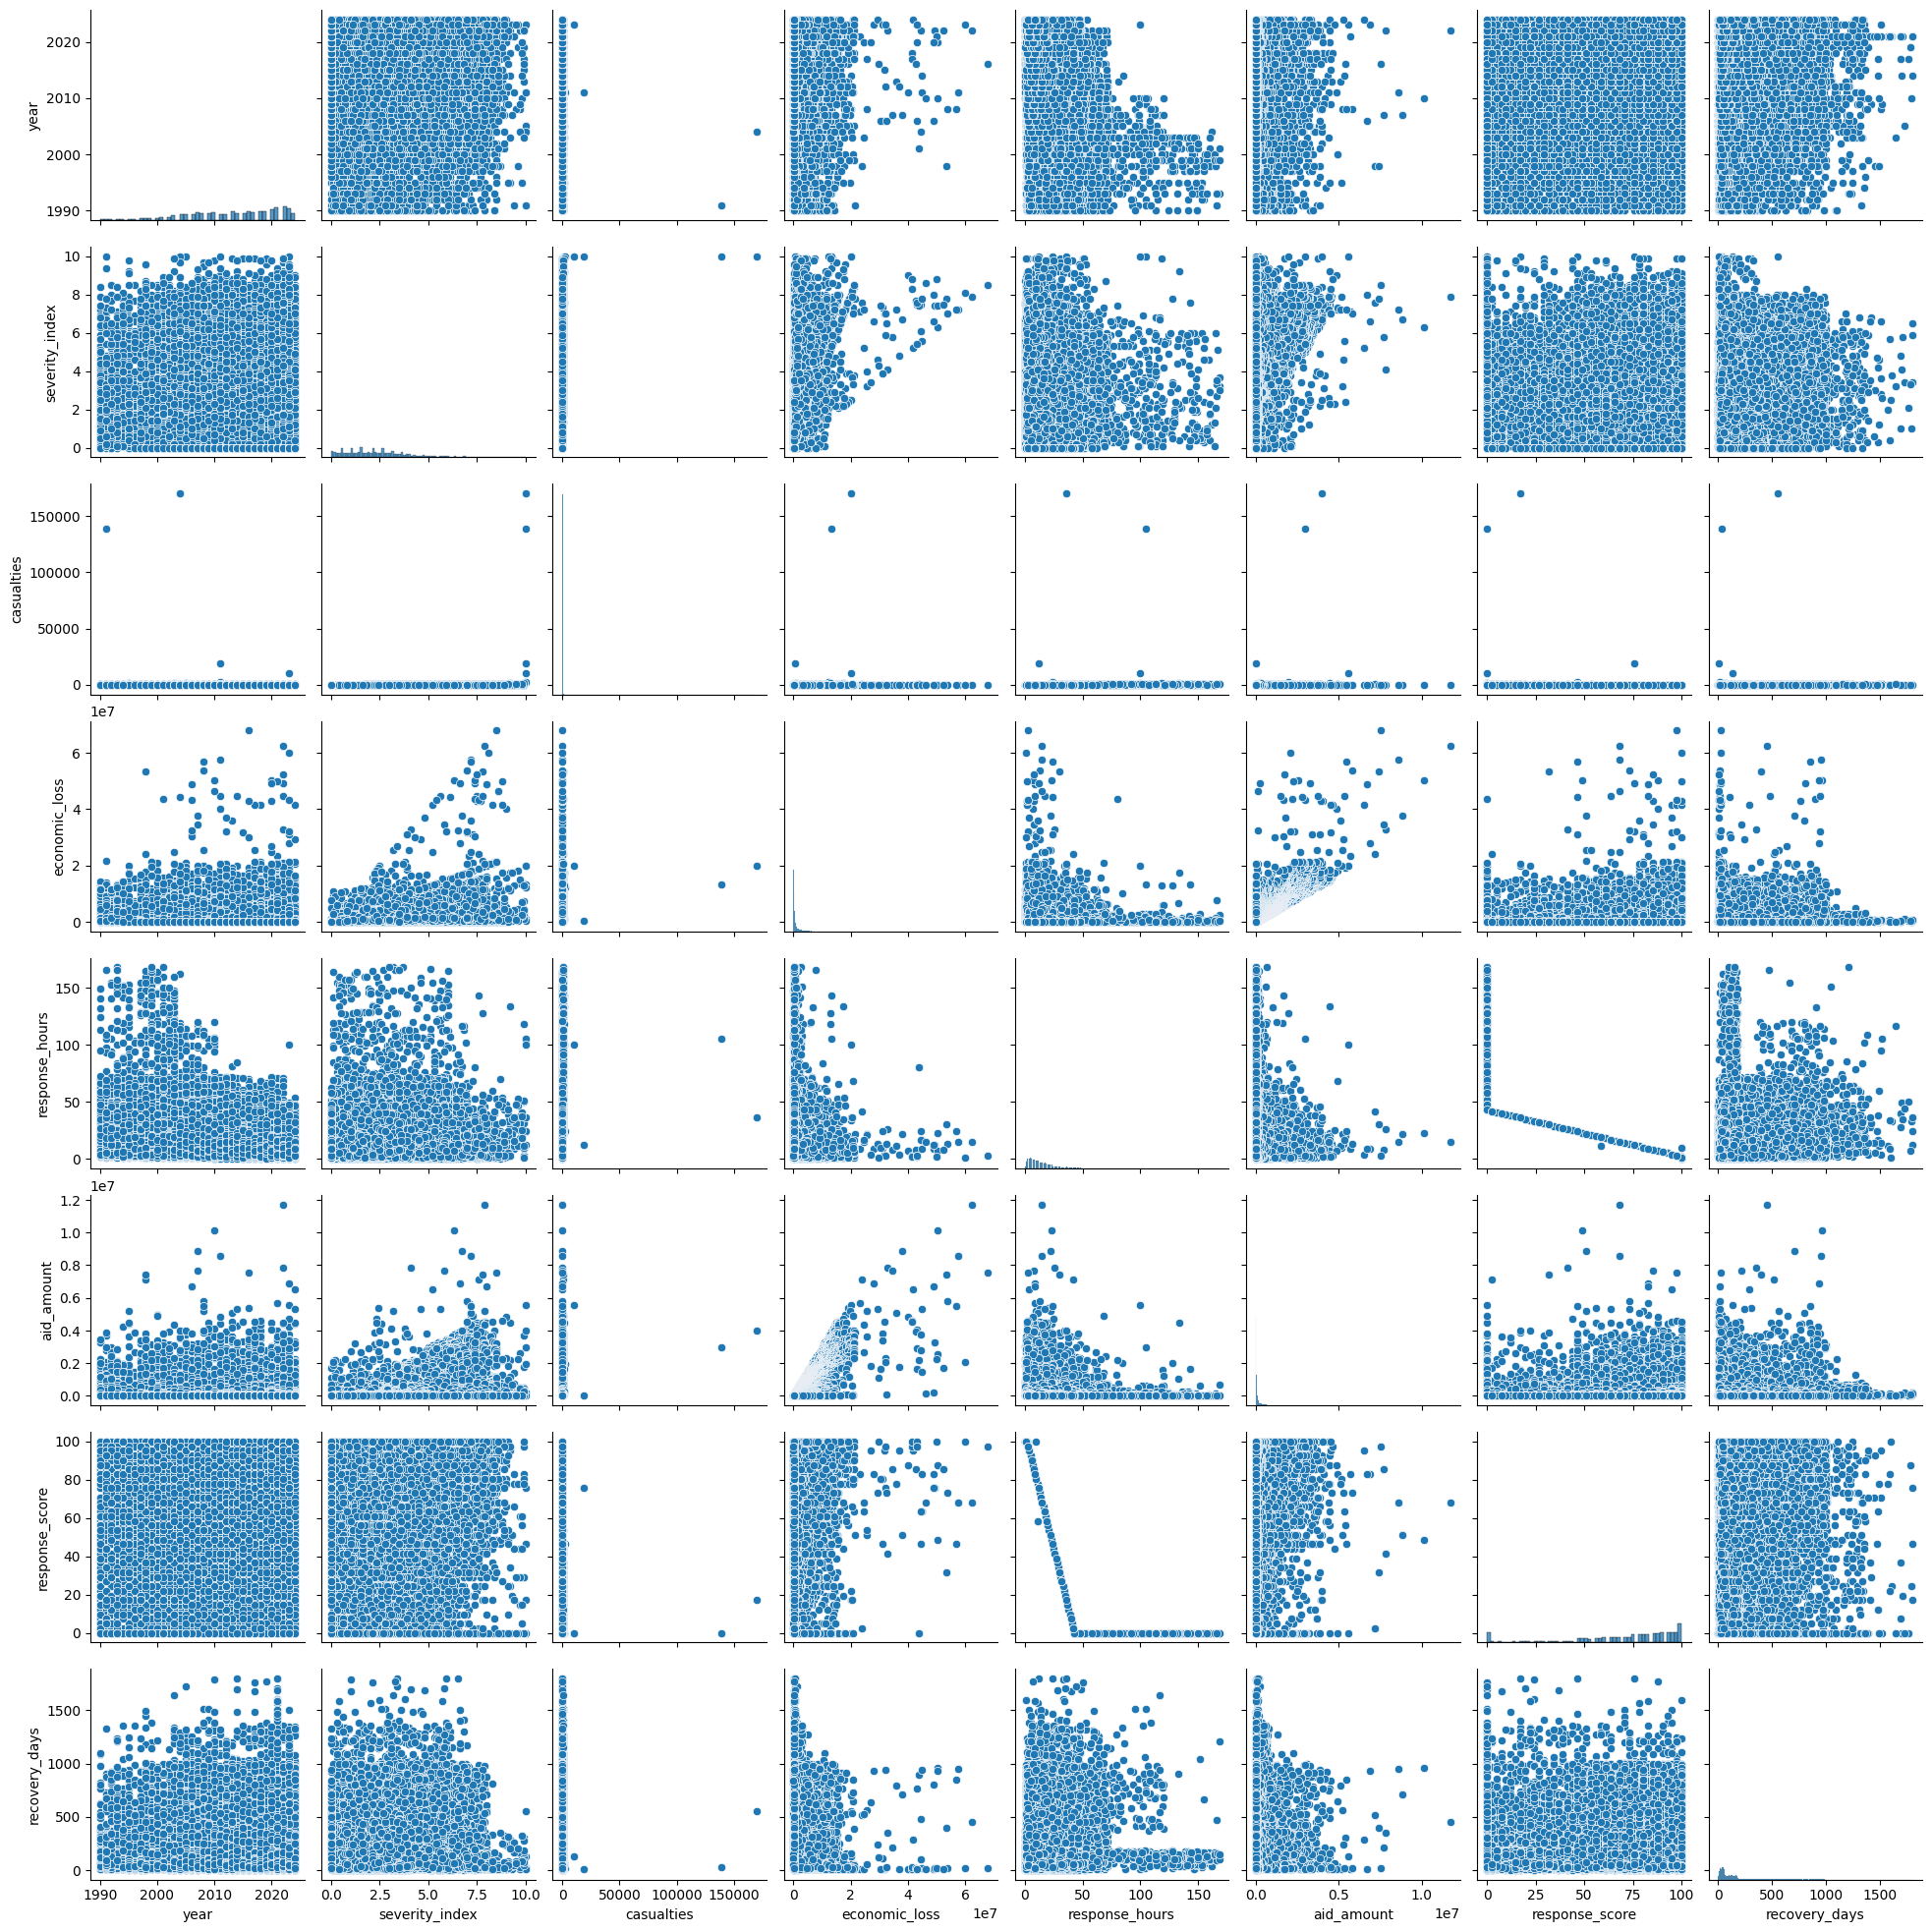

In [61]:
sns.pairplot(df);

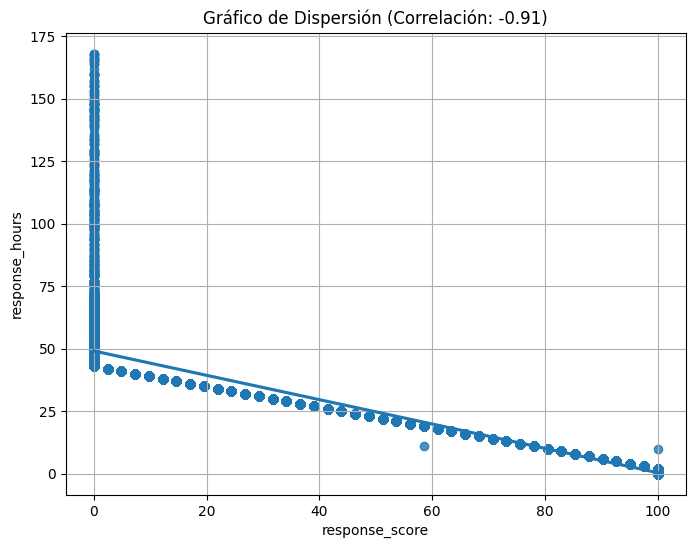

In [90]:
correlacion = df['response_score'].corr(df['response_hours'])

plt.figure(figsize=(8, 6))
sns.regplot(x='response_score', y='response_hours', data=df)
plt.title(f'Gráfico de Dispersión (Correlación: {correlacion:.2f})')
plt.grid(True)
plt.show();

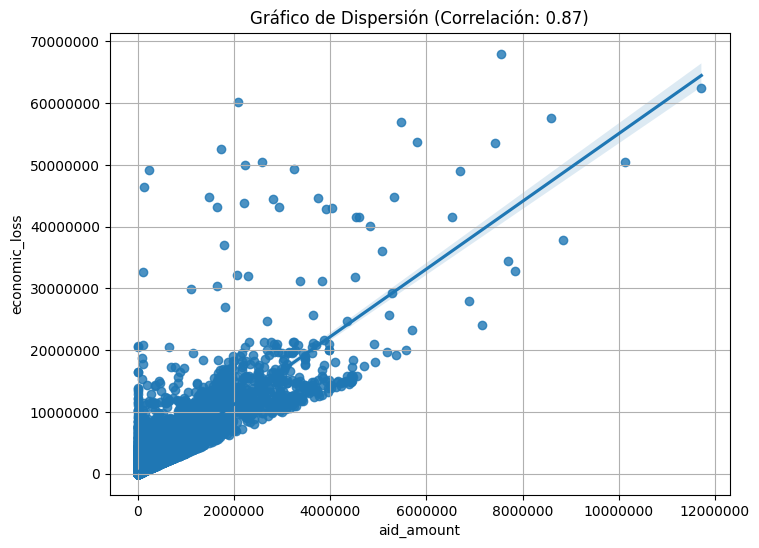

In [93]:
correlacion = df['aid_amount'].corr(df['economic_loss'])

plt.figure(figsize=(8, 6))
sns.regplot(x='aid_amount', y='economic_loss', data=df)
plt.ticklabel_format(style='plain', axis='both')
plt.title(f'Gráfico de Dispersión (Correlación: {correlacion:.2f})')
plt.grid(True)
plt.show();

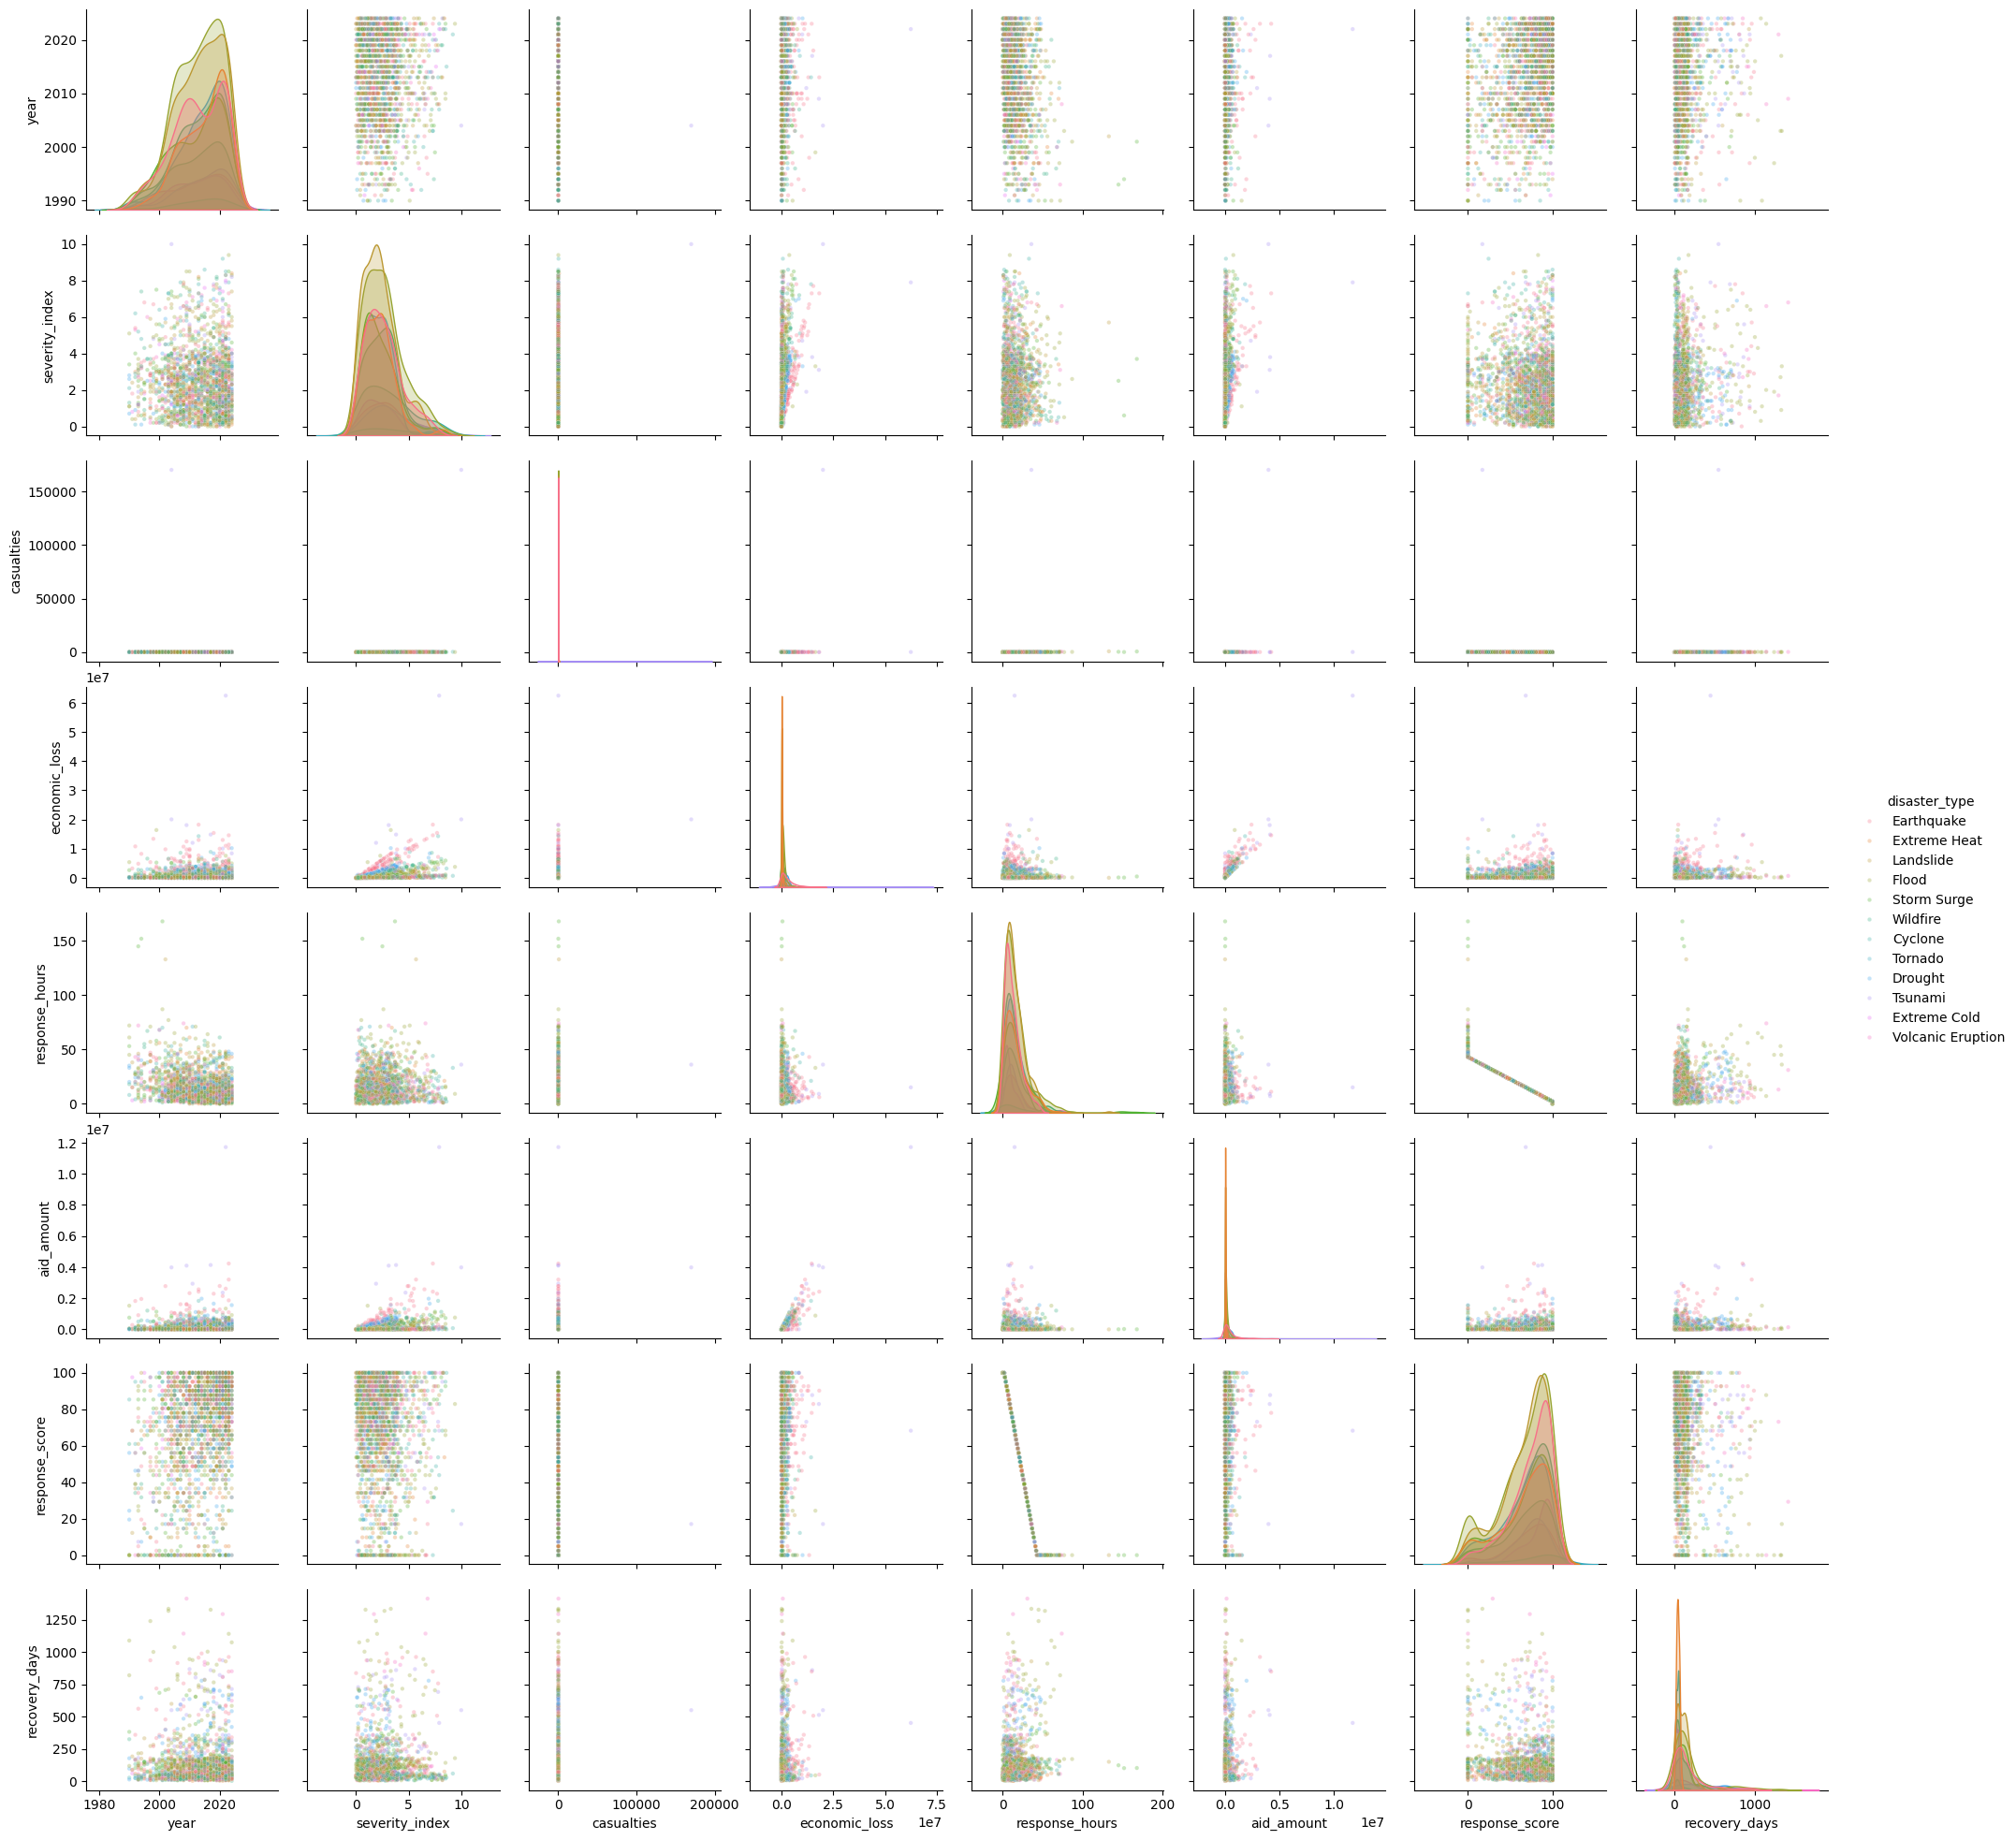

In [106]:
sns.pairplot(df.sample(2000), hue='disaster_type', plot_kws=dict(alpha=0.3, s=10))

C:\Users\cchia\AppData\Local\Temp\ipykernel_30828\1087256561.py:24: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('gist_rainbow', len(paises_unicos))


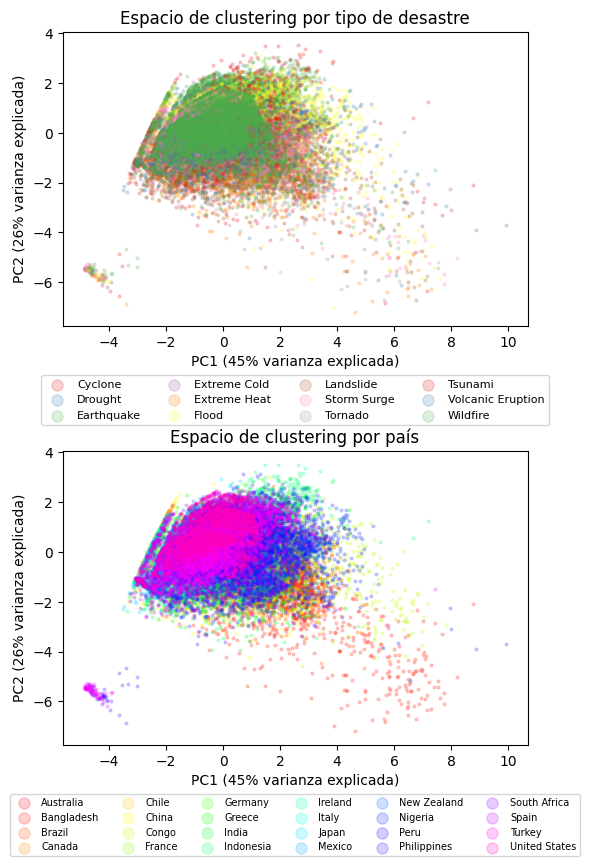

In [ ]:
from matplotlib.colors import to_hex
import matplotlib.cm as cm

fig, axes = plt.subplots(1, 2, figsize=(6, 10))

# --- Por tipo de desastre ---
tipos_unicos = sorted(df['disaster_type'].unique())
palette_tipo = sns.color_palette("Set1", len(tipos_unicos))

for i, tipo in enumerate(tipos_unicos):
    mask = df['disaster_type'].values == tipo
    axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1],
                    color=palette_tipo[i], label=tipo,
                    alpha=0.2, s=4)

axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.0%} varianza explicada)')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.0%} varianza explicada)')
axes[0].set_title('Espacio de clustering por tipo de desastre')
axes[0].legend(markerscale=4, fontsize=8,
               bbox_to_anchor=(0.5, -0.15), loc='upper center', ncol=4)

# --- Por país ---
paises_unicos = sorted(df['country'].unique())
cmap = cm.get_cmap('gist_rainbow', len(paises_unicos))
palette_pais = [to_hex(cmap(i)) for i in range(len(paises_unicos))]

for i, pais in enumerate(paises_unicos):
    mask = df['country'].values == pais
    axes[1].scatter(X_pca[mask, 0], X_pca[mask, 1],
                    color=palette_pais[i], label=pais,
                    alpha=0.2, s=4)

axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.0%} varianza explicada)')
axes[1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.0%} varianza explicada)')
axes[1].set_title('Espacio de clustering por país')
axes[1].legend(markerscale=4, fontsize=7,
               bbox_to_anchor=(0.5, -0.15), loc='upper center', ncol=6)

plt.tight_layout()
plt.subplots_adjust(bottom=0.25)
plt.show();

PCA (Análisis de Componentes Principales) es una técnica que toma tus 4 variables originales — casualties, economic_loss, response_hours, recovery_days — y las combina en nuevas variables llamadas componentes principales, que son combinaciones lineales de las originales. Las construye de forma que PC1 capture la mayor varianza posible del dataset, PC2 la segunda mayor, y así sucesivamente.
En tu caso:

PC1 (45%) es una combinación de tus 4 variables que explica el 45% de toda la variabilidad del dataset. Probablemente está capturando el "nivel general de gravedad + lentitud de respuesta" — eventos con muchas víctimas, pérdidas altas y recuperación lenta quedan a un lado, eventos leves y rápidos al otro.
PC2 (26%) captura una segunda dimensión independiente de PC1. Podría estar separando, por ejemplo, eventos con muchas víctimas pero pérdidas económicas bajas de eventos con pocas víctimas pero pérdidas altas — dos perfiles que PC1 trataría igual.

Juntos explican el 71% de la varianza, lo que significa que este gráfico 2D es una representación bastante fiel del espacio original de 4 dimensiones.

In [122]:
# 1. Cogemos las 4 variables
cols_clustering = ['casualties', 'economic_loss', 'response_hours', 'recovery_days']

# 2. Log1p en las que tienen outliers extremos
df_clust = df[cols_clustering].copy()
df_clust['casualties']    = np.log1p(df['casualties'])
df_clust['economic_loss'] = np.log1p(df['economic_loss'])

# 3. Estandarizamos — PCA es sensible a la escala
X = StandardScaler().fit_transform(df_clust)

# 4. PCA reduce de 4 dimensiones a 2
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)
# X_pca tiene shape (49972, 2) — un punto 2D por cada evento

In [123]:
pd.DataFrame(pca.components_, 
             columns=cols_clustering,
             index=['PC1', 'PC2']).round(3)

,casualties,economic_loss,response_hours,recovery_days
PC1,0.665,0.359,0.572,0.318
PC2,-0.056,0.807,-0.553,0.200


Gráfico izquierdo — por tipo de desastre  
Los tipos de desastre están completamente mezclados en toda la masa principal. No hay ninguna zona donde un color domine claramente — todos conviven en el mismo espacio. Esto confirma que el tipo de desastre por sí solo no define el perfil de riesgo: hay tsunamis leves y tornados graves que ocupan la misma posición en el espacio.
La única excepción es el grupo aislado abajo a la izquierda, donde parece haber algo más de concentración de colores concretos — vale la pena ejecutar el código que te di antes para identificarlos.

Gráfico derecho — por país  
Aquí sí hay algo más de estructura. La masa central densa (PC1 entre −2 y 2) está dominada por el magenta/rosa fuerte — que según la leyenda es Brasil o Bangladesh — pero sobre todo hay muchísima mezcla. Sin embargo, en el brazo derecho (PC1 > 4, eventos de mayor impacto) se intuyen colores distintos a los del centro, lo que sugiere que ciertos países concentran los eventos más extremos.
El grupo aislado de abajo a la izquierda parece tener colores bastante homogéneos — mayoritariamente uno o dos países. Eso es la pista más interesante: ese grupo aislado probablemente corresponde a eventos de un país concreto con una combinación muy particular de variables (por ejemplo, recovery_days extremadamente alto con casualties bajo, o al revés).

El espacio tiene estructura (no es ruido aleatorio), pero los grupos naturales no coinciden con las categorías existentes de país ni tipo de desastre. Los clusters que va a encontrar K-Means van a ser transversales — mezclarán países y tipos, y los definirá el nivel de impacto y la velocidad de respuesta, no la etiqueta geográfica o el tipo de fenómeno. Eso es exactamente lo interesante del clustering para tu objetivo.

In [ ]:
# grupo gráfico izq 

mask_aislado = (X_pca[:, 0] < -3) & (X_pca[:, 1] < -4)
print(df[mask_aislado][['country', 'disaster_type', 'casualties', 
                          'economic_loss', 'response_hours', 'recovery_days']])

           country      disaster_type  casualties  economic_loss  \
49609  Philippines       Extreme Heat           0            0.0   
49617  Philippines         Earthquake           0            0.0   
49618       Turkey       Extreme Cold           0            0.0   
49619  Philippines            Cyclone           0            0.0   
49620  Philippines            Cyclone           0            0.0   
49630       Turkey        Storm Surge           0            0.0   
49637       Turkey        Storm Surge           0            0.0   
49638  Philippines              Flood           0            0.0   
49639       Turkey       Extreme Cold           0            0.0   
49648  Philippines       Extreme Heat           0            0.0   
49649  Philippines       Extreme Heat           0            0.0   
49650       Turkey           Wildfire           0            0.0   
49666  Philippines            Cyclone           0            0.0   
49667  Philippines            Cyclone           

Qué estás viendo en estos dos gráficos, explicado simple:
Imagina que tienes 50.000 desastres y cada uno tiene 4 números: víctimas, pérdidas económicas, horas de respuesta y días de recuperación. Es imposible dibujar algo con 4 dimensiones, así que el PCA lo que hace es aplastar esas 4 dimensiones en 2, como si aplastaras una esfera en un papel — pierdes algo de información pero puedes verlo.
Cada punto en el gráfico es un desastre. Su posición depende de sus 4 valores combinados. Puntos cercanos = desastres parecidos. Puntos lejos = desastres muy distintos.

Lo que ves:
La masa grande del centro son la mayoría de desastres — normales, ni muy graves ni muy leves.
El brazo que se estira hacia la derecha son los desastres más extremos en impacto o en tiempo de recuperación.
El grupito aislado abajo a la izquierda son unos pocos eventos muy raros, con una combinación de valores muy diferente al resto.

Lo importante: cuando coloreas por tipo de desastre o por país, los colores están completamente mezclados en todas partes. No hay una zona que sea "solo tsunamis" o "solo Congo". Un tsunami puede estar al lado de una sequía porque tuvieron impacto y respuesta similares.

El clustering te da un único conjunto de clusters basado en las 4 variables. Cada evento recibe una sola etiqueta de cluster. No hay dos agrupaciones paralelas.
Lo que harías después es analizar esos mismos clusters desde dos ángulos:

¿Qué países concentra cada cluster? → crosstab cluster × country
¿Qué tipos de desastre concentra cada cluster? → crosstab cluster × disaster_type

Son dos formas de mirar el mismo resultado, no dos clusterings distintos.